<a href="https://colab.research.google.com/github/jamesalphonso36-la/CSL701-CE08_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Column names
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Load dataset
df = pd.read_csv(
    "diabetes.csv",
    header=None,
    names=columns
)

# First five records
print("First five records:")
print(df.head())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

First five records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35    169.5  33.6   
2            1       85             66             29    102.5  26.6   
3            8      183             64             32    169.5  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  

Dataset Shape:
(769, 9)

Data Types:
Pregnancies                 object
Glucose                     object
BloodPressure               object
SkinThickness               object
Insulin                     object
BMI                         object
DiabetesPedigreeFunction    object


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


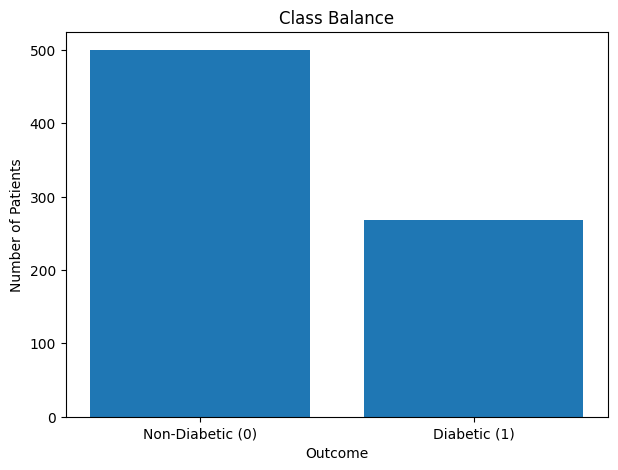

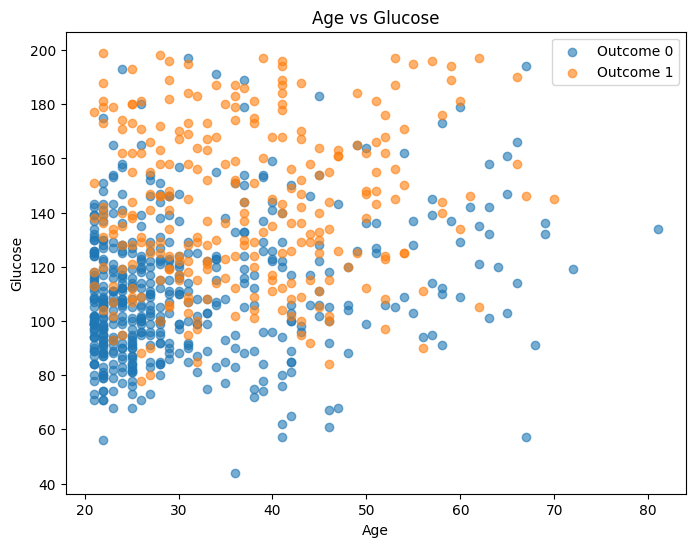


Explanation:
A simple linear decision boundary is insufficient because the diabetic
and non-diabetic classes overlap in the feature space. Diabetes depends
on multiple features such as glucose, BMI, age, blood pressure and
other factors. Therefore, a single straight-line boundary cannot
clearly separate all the classes.



In [4]:
import pandas as pd

# Create a temporary DataFrame to clean for this cell's operations
temp_df = df.copy()

# Drop the first row which was incorrectly read as the header row data
temp_df = temp_df.iloc[1:].copy()

# Convert columns to numeric types, coercing errors to NaN
# Note: 'Outcome' will be converted to int after handling NaNs if any, or directly if no NaNs
for col in temp_df.columns:
    if col != 'Outcome':
        temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
    else:
        temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce').astype(int)

# Class count
class_counts = temp_df["Outcome"].value_counts().sort_index()

# Class percentage
class_percentages = temp_df["Outcome"].value_counts(
    normalize=True
).sort_index() * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)

# Bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    class_counts.values
)

plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.title("Class Balance")

plt.show()


# Scatter plot: Age vs Glucose
plt.figure(figsize=(8, 6))

for outcome in [0, 1]:
    # Now 'temp_df["Outcome"]' contains integer values, so comparison works
    subset = temp_df[temp_df["Outcome"] == outcome]

    plt.scatter(
        subset["Age"],
        subset["Glucose"],
        label=f"Outcome {outcome}",
        alpha=0.6
    )

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose")
plt.legend()

plt.show()

print("""
Explanation:
A simple linear decision boundary is insufficient because the diabetic
and non-diabetic classes overlap in the feature space. Diabetes depends
on multiple features such as glucose, BMI, age, blood pressure and
other factors. Therefore, a single straight-line boundary cannot
clearly separate all the classes.
""")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [7]:
# Features where zero is physically impossible
invalid_zero_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Drop the first row which was incorrectly read as the header row data
df = df.iloc[1:].copy()

# Convert columns to numeric types, coercing errors to NaN
for col_name in df.columns:
    if col_name == 'Outcome':
        # Outcome should be integer
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce').astype(int)
    else:
        # Other features
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# Count zeros before replacement
print("Zero values before replacement:")
for column in invalid_zero_features:
    print(f"{column}: {(df[column] == 0).sum()}")

# Replace zero with NaN
df[invalid_zero_features] = df[invalid_zero_features].replace(0, np.nan)

print("\nMissing values after replacing zeros:")
print(df.isnull().sum())

# Impute missing values using median
for column in invalid_zero_features:
    median_val = df[column].median()
    df[column] = df[column].fillna(median_val)

print("\nMissing values after median imputation:")
print(df.isnull().sum())

Zero values before replacement:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0

Missing values after replacing zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [8]:
# Feature matrix X
X = df.iloc[:, :8]

# Target vector y
y = df.iloc[:, 8]

# Stratified 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (614, 8)
Testing data shape: (154, 8)

Training class distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [9]:
def get_bootstrap_sample(X, y):
    """
    Generate a bootstrap sample of the same size as the
    training data using sampling with replacement.
    """

    n_samples = len(X)

    # Random indices with replacement
    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices].reset_index(drop=True)
    y_bootstrap = y.iloc[indices].reset_index(drop=True)

    return X_bootstrap, y_bootstrap, indices


# Test the bootstrap function
np.random.seed(42)

X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

print("Original training size:", len(X_train))
print("Bootstrap sample size:", len(X_bootstrap))

# Count duplicated indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

# OOB indices
all_indices = set(range(len(X_train)))
selected_indices = set(bootstrap_indices)

oob_indices = sorted(
    all_indices - selected_indices
)

print("\nNumber of unique sampled rows:",
      len(unique_indices))

print("Number of duplicated rows:",
      len(duplicated_indices))

print("Number of OOB rows:",
      len(oob_indices))

print("\nSome duplicated indices:")
print(duplicated_indices[:10])

print("\nSome OOB indices:")
print(oob_indices[:10])

Original training size: 614
Bootstrap sample size: 614

Number of unique sampled rows: 377
Number of duplicated rows: 164
Number of OOB rows: 237

Some duplicated indices:
[ 1  4  8 11 14 20 21 27 32 34]

Some OOB indices:
[2, 3, 5, 6, 10, 12, 23, 25, 29, 30]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [10]:
# Number of estimators
B = 50

# Store trained decision trees
ensemble = []

np.random.seed(42)

for i in range(B):

    # Generate bootstrap sample
    X_bootstrap, y_bootstrap, indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create fully grown decision tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=42 + i
    )

    # Train model
    model.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Store model
    ensemble.append(model)


print("Number of decision trees in ensemble:", len(ensemble))

Number of decision trees in ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [11]:
def custom_bagging_predict(ensemble, X_test):
    """
    Generate predictions using majority voting
    from all decision trees.
    """

    # Collect predictions from every tree
    predictions = []

    for model in ensemble:
        pred = model.predict(X_test)
        predictions.append(pred)

    # Convert to NumPy array
    predictions = np.array(predictions)

    # Majority voting
    final_predictions = []

    for i in range(predictions.shape[1]):

        votes = predictions[:, i]

        # Count votes for each class
        counts = np.bincount(votes.astype(int))

        # Select class with maximum votes
        majority_class = np.argmax(counts)

        final_predictions.append(majority_class)

    return np.array(final_predictions)


# Generate Bagging predictions
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("Bagging predictions:")
print(y_pred_bagging)

print("\nUnique predicted classes:")
print(np.unique(y_pred_bagging))

Bagging predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]

Unique predicted classes:
[0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


Single Decision Tree
Accuracy : 0.8116883116883117
Precision: 0.7450980392156863
Recall   : 0.7037037037037037
F1-Score : 0.7238095238095238

Confusion Matrix:
[[87 13]
 [16 38]]

Custom Bagging
Accuracy : 0.8636363636363636
Precision: 0.8113207547169812
Recall   : 0.7962962962962963
F1-Score : 0.8037383177570093

Confusion Matrix:
[[90 10]
 [11 43]]


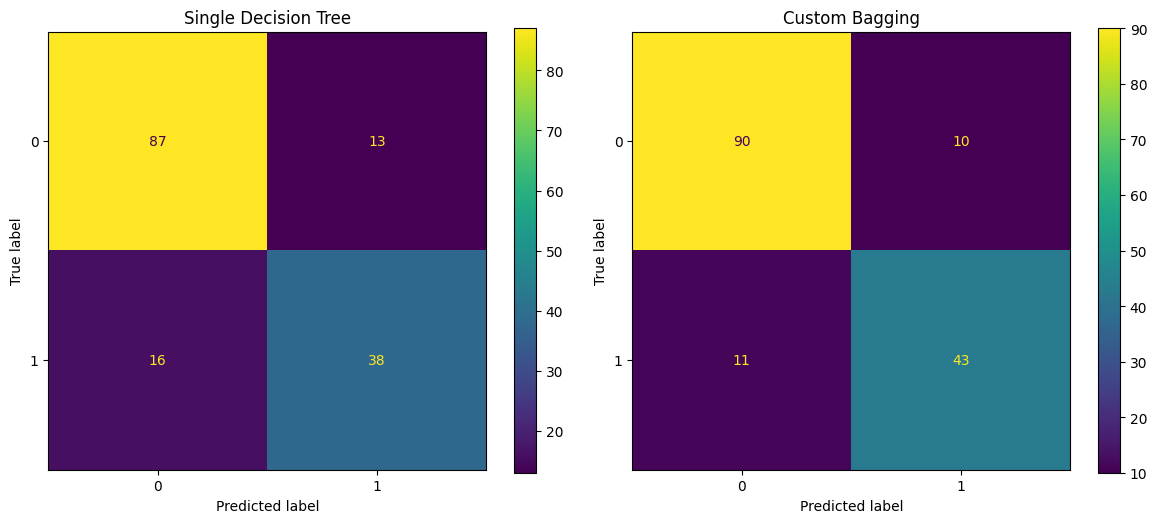

In [12]:
# Train a single fully-grown decision tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(
    X_train,
    y_train
)

# Predictions from single tree
y_pred_single = single_tree.predict(X_test)

# Predictions from Bagging
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# Function to display metrics
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n", "=" * 40)
    print(name)
    print("=" * 40)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    return accuracy, precision, recall, f1


# Evaluate single tree
single_metrics = evaluate_model(
    "Single Decision Tree",
    y_test,
    y_pred_single
)

# Evaluate Bagging
bagging_metrics = evaluate_model(
    "Custom Bagging",
    y_test,
    y_pred_bagging
)


# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_single,
    ax=axes[0]
)

axes[0].set_title("Single Decision Tree")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_bagging,
    ax=axes[1]
)

axes[1].set_title("Custom Bagging")

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.7868518518518519
Custom Bagging AUC: 0.9481481481481482


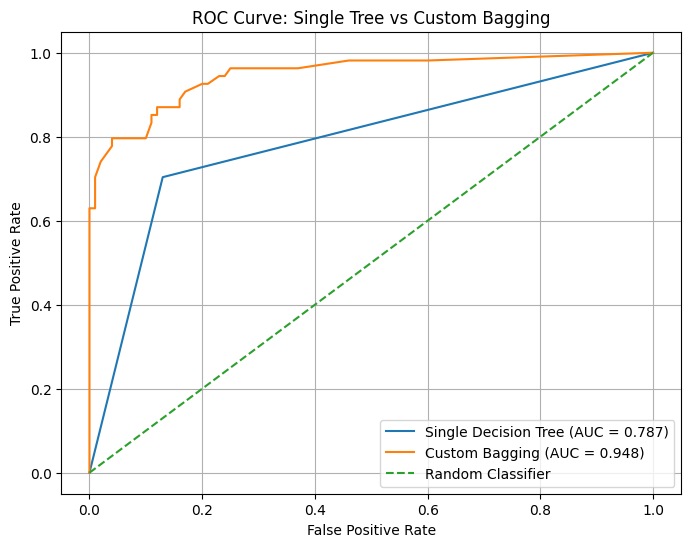

In [13]:
# Single Decision Tree probabilities
single_probabilities = single_tree.predict_proba(X_test)[:, 1]


# Get probability predictions from all trees
all_probabilities = []

for model in ensemble:
    probabilities = model.predict_proba(X_test)[:, 1]
    all_probabilities.append(probabilities)

all_probabilities = np.array(all_probabilities)

# Average probability across all trees
bagging_probabilities = np.mean(
    all_probabilities,
    axis=0
)


# Calculate ROC curves
fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    single_probabilities
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    bagging_probabilities
)


# Calculate AUC
auc_single = roc_auc_score(
    y_test,
    single_probabilities
)

auc_bagging = roc_auc_score(
    y_test,
    bagging_probabilities
)


print("Single Decision Tree AUC:", auc_single)
print("Custom Bagging AUC:", auc_bagging)


# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Tree vs Custom Bagging")
plt.legend()
plt.grid()

plt.show()


#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [14]:
from sklearn.ensemble import BaggingClassifier

# Create base estimator
base_tree = DecisionTreeClassifier(
    max_depth=None
)

# Create built-in BaggingClassifier
sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)

# Train
sklearn_bagging.fit(
    X_train,
    y_train
)

# Predict
y_pred_sklearn = sklearn_bagging.predict(X_test)

# Accuracy
sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

print("Scikit-Learn Bagging Accuracy:",
      sklearn_accuracy)


# Confusion Matrix
sklearn_cm = confusion_matrix(
    y_test,
    y_pred_sklearn
)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(sklearn_cm)


# Full evaluation
evaluate_model(
    "Scikit-Learn BaggingClassifier",
    y_test,
    y_pred_sklearn
)


# Compare all models
comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Custom Bagging",
        "Scikit-Learn Bagging"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_single),
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_sklearn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_single, zero_division=0),
        precision_score(y_test, y_pred_bagging, zero_division=0),
        precision_score(y_test, y_pred_sklearn, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_single, zero_division=0),
        recall_score(y_test, y_pred_bagging, zero_division=0),
        recall_score(y_test, y_pred_sklearn, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_single, zero_division=0),
        f1_score(y_test, y_pred_bagging, zero_division=0),
        f1_score(y_test, y_pred_sklearn, zero_division=0)
    ]
})

print("\nFinal Model Comparison:")
print(comparison)

Scikit-Learn Bagging Accuracy: 0.8831168831168831

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]

Scikit-Learn BaggingClassifier
Accuracy : 0.8831168831168831
Precision: 0.8333333333333334
Recall   : 0.8333333333333334
F1-Score : 0.8333333333333334

Confusion Matrix:
[[91  9]
 [ 9 45]]

Final Model Comparison:
                  Model  Accuracy  Precision    Recall  F1-Score
0  Single Decision Tree  0.811688   0.745098  0.703704  0.723810
1        Custom Bagging  0.863636   0.811321  0.796296  0.803738
2  Scikit-Learn Bagging  0.883117   0.833333  0.833333  0.833333


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?